# Простейшие операции с изображениями с использованием Open CV. Поиск объекта на цветном изображении

In [156]:
import cv2 # импорт Open CV
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [157]:
# считываем данные графических файлой в переменные
bus = cv2.cvtColor(cv2.imread('bus.jpg'), cv2.COLOR_BGR2RGB)
car = cv2.cvtColor(cv2.imread('car.jpg'), cv2.COLOR_BGR2RGB)
fox = cv2.cvtColor(cv2.imread('fox.jpg'), cv2.COLOR_BGR2RGB)
tennis_ball = cv2.cvtColor(cv2.imread('tennis_ball.jpg'), cv2.COLOR_BGR2RGB)
aivazovsky = np.array(Image.open('Айвазовский.jpg')) # считываем через PIL из-за проблемы с расширением файла
horse = np.array(Image.open('лошадь.jpg')) # считываем через PIL из-за проблемы с расширением файла

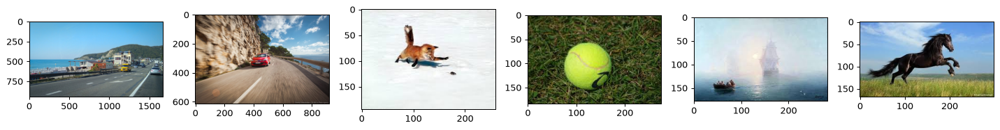

In [158]:
plt.figure(figsize=(16,13), dpi=90)
plt.subplot(1,6,1); plt.imshow(bus)
plt.subplot(1,6,2); plt.imshow(car)
plt.subplot(1,6,3); plt.imshow(fox)
plt.subplot(1,6,4); plt.imshow(tennis_ball)
plt.subplot(1,6,5); plt.imshow(aivazovsky)
plt.subplot(1,6,6); plt.imshow(horse)
plt.tight_layout()
plt.show()

In [159]:
# получaем полутоновое изображение
bus_gray = cv2.cvtColor(bus, cv2.COLOR_RGB2GRAY)
car_gray = cv2.cvtColor(car, cv2.COLOR_RGB2GRAY)
fox_gray = cv2.cvtColor(fox, cv2.COLOR_RGB2GRAY)
tennis_ball_gray = cv2.cvtColor(tennis_ball, cv2.COLOR_RGB2GRAY)
aivazovsky_gray = cv2.cvtColor(aivazovsky, cv2.COLOR_RGB2GRAY)
horse_gray = cv2.cvtColor(horse, cv2.COLOR_RGB2GRAY)

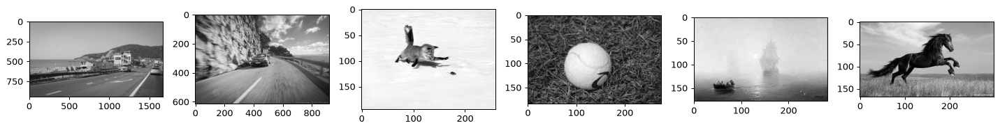

In [160]:
plt.figure(figsize=(16,13), dpi=90)
plt.subplot(1,6,1); plt.imshow(bus_gray, cmap='gray')
plt.subplot(1,6,2); plt.imshow(car_gray, cmap='gray')
plt.subplot(1,6,3); plt.imshow(fox_gray, cmap='gray')
plt.subplot(1,6,4); plt.imshow(tennis_ball_gray, cmap='gray')
plt.subplot(1,6,5); plt.imshow(aivazovsky_gray, cmap='gray')
plt.subplot(1,6,6); plt.imshow(horse_gray, cmap='gray')
plt.tight_layout()
plt.show()

In [161]:
def resize(img, height=400):
    # Нам надо сохранить соотношение сторон, чтобы изображение не исказилось при изменении размера
    # для этого рассчитаем коэффициент res_img
    print(f'Размер исходного изображения: {img.shape[1]}:{img.shape[0]}')
    res_img = float(height) / img.shape[0]
    dim = (int(img.shape[1] * res_img), height)

    # выбираем интерполяцию в зависимости от res_img
    if res_img <= 1:
        interpolation = cv2.INTER_AREA # из документации open_cv при уменьшенни лучше INTER_AREA
        print('Выбарана интерполяция: cv2.INTER_AREA')
    else:
        interpolation = cv2.INTER_CUBIC # из документации open_cv при увеличении лучше INTER_CUBIC
        print('Выбарана интерполяция: cv2.INTER_CUBIC')

    # уменьшаем изображение до подготовленных размеров
    resized = cv2.resize(img, dim, interpolation = interpolation)
    print(f'Размер отскейленного изображения: {resized.shape[1]}:{resized.shape[0]}')
    plt.imshow(resized)

Размер исходного изображения: 1672:941
Выбарана интерполяция: cv2.INTER_AREA
Размер отскейленного изображения: 710:400


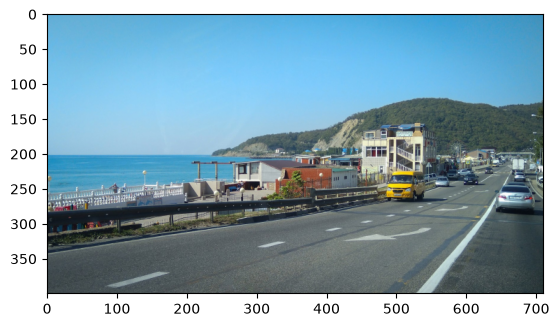

In [162]:
resize(bus)

Размер исходного изображения: 918:612
Выбарана интерполяция: cv2.INTER_AREA
Размер отскейленного изображения: 600:400


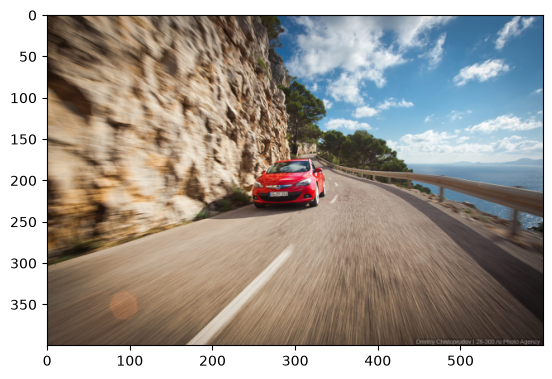

In [163]:
resize(car)

Размер исходного изображения: 259:194
Выбарана интерполяция: cv2.INTER_CUBIC
Размер отскейленного изображения: 534:400


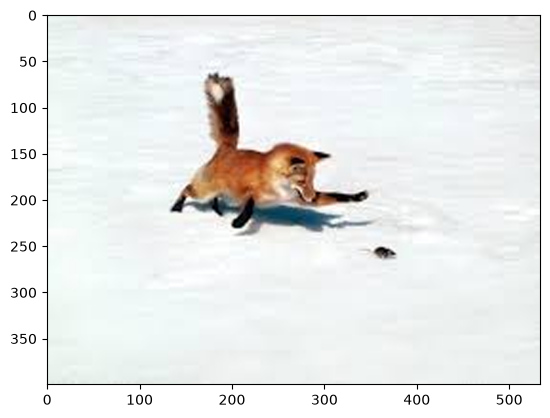

In [164]:
resize(fox)

Размер исходного изображения: 276:183
Выбарана интерполяция: cv2.INTER_CUBIC
Размер отскейленного изображения: 603:400


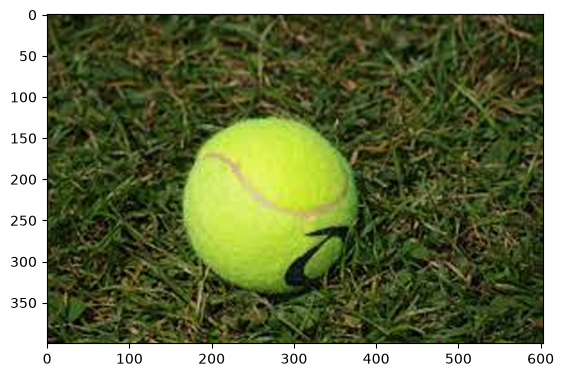

In [165]:
resize(tennis_ball)

Размер исходного изображения: 283:178
Выбарана интерполяция: cv2.INTER_CUBIC
Размер отскейленного изображения: 635:400


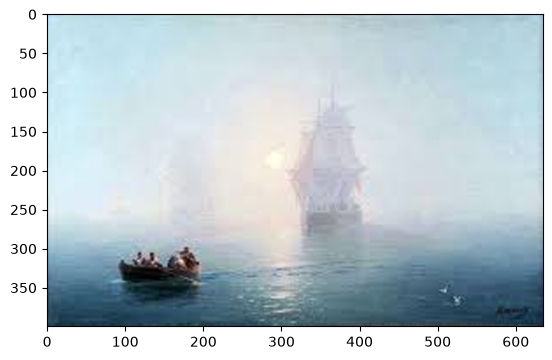

In [166]:
resize(aivazovsky)

Размер исходного изображения: 299:168
Выбарана интерполяция: cv2.INTER_CUBIC
Размер отскейленного изображения: 711:400


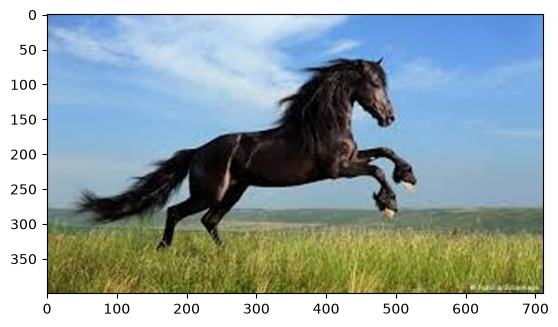

In [167]:
resize(horse)

In [168]:
def rotate(img):
    (h, w) = img.shape[:2]
    center = (w / 2, h / 2)

    # повернем изображение на 180 градусов
    M = cv2.getRotationMatrix2D(center, 180, 1)
    rotated180 = cv2.warpAffine(img, M, (w, h))
    # повернем изображение на 90 градусов
    M = cv2.getRotationMatrix2D(center, 90, 1)
    rotated90 = cv2.warpAffine(img, M, (w, h))
    plt.figure(figsize=(16,13), dpi=90)
    plt.subplot(1,3,1); plt.imshow(img); plt.title('Исходное изображение')
    plt.subplot(1,3,2); plt.imshow(rotated180); plt.title('180')
    plt.subplot(1,3,3); plt.imshow(rotated90); plt.title('90')
    plt.tight_layout()
    plt.show()

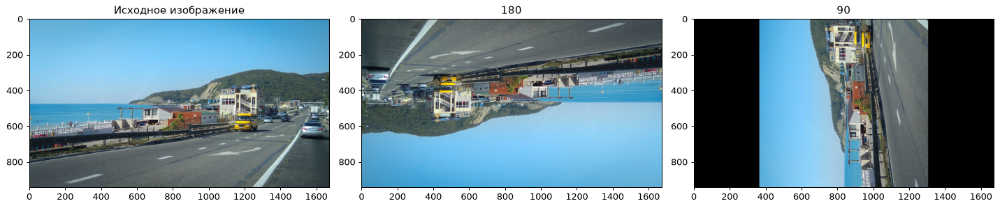

In [169]:
rotate(bus)

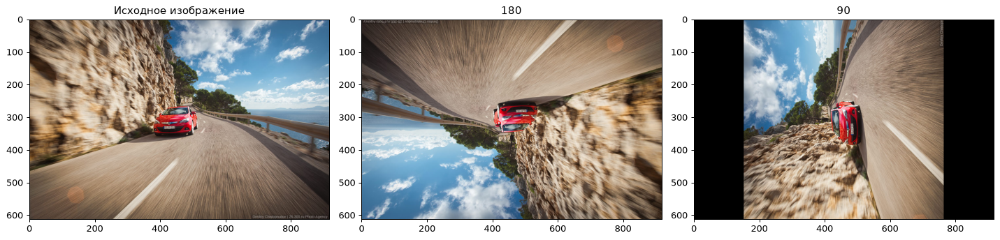

In [170]:
rotate(car)

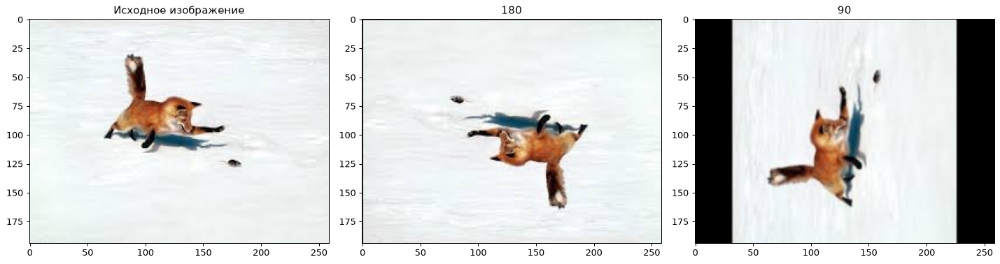

In [171]:
rotate(fox)

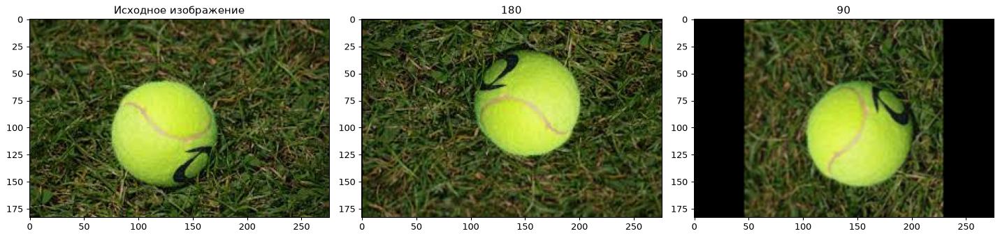

In [172]:
rotate(tennis_ball)

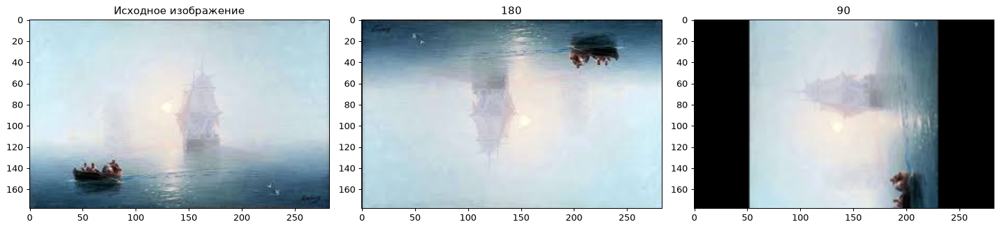

In [173]:
rotate(aivazovsky)

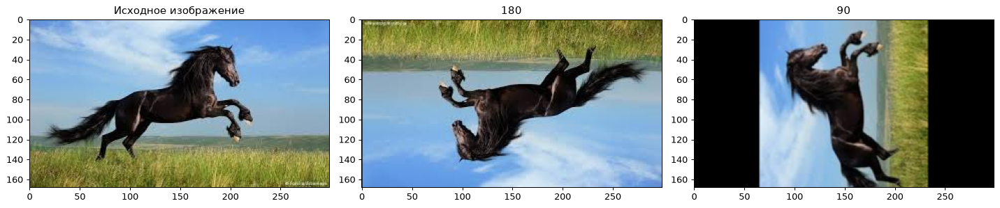

In [174]:
rotate(horse)

In [175]:
# функций для отражение изображения по осям
def flip(img):
    plt.figure(figsize=(16,13), dpi=90)
    plt.subplot(1,3,1); plt.imshow(img); plt.title('Исходное изображение')
    plt.subplot(1,3,2); plt.imshow(cv2.flip(img,1)); plt.title('Отраженное по горизонтали')
    plt.subplot(1,3,3); plt.imshow(cv2.flip(img,0)); plt.title('Отраженное по вертикали')
    plt.tight_layout()
    plt.show()

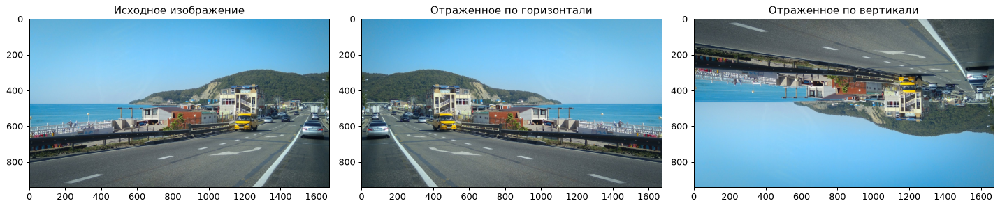

In [176]:
flip(bus)

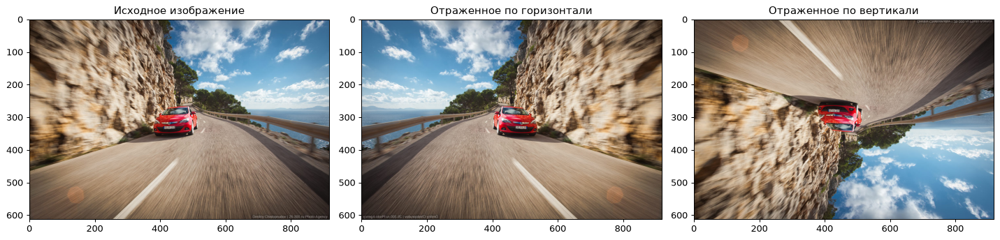

In [177]:
flip(car)

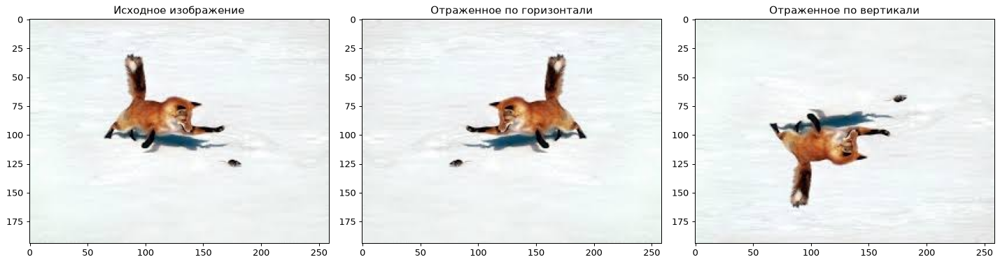

In [178]:
flip(fox)

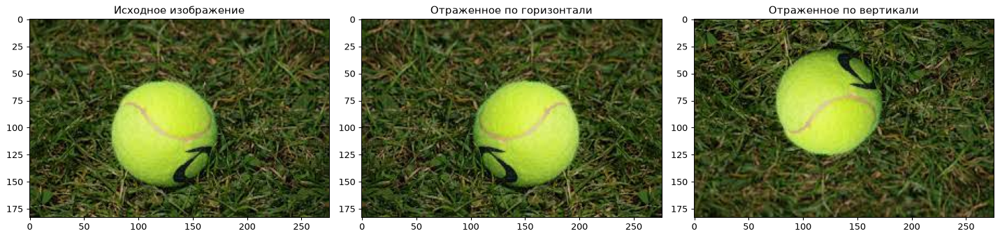

In [179]:
flip(tennis_ball)

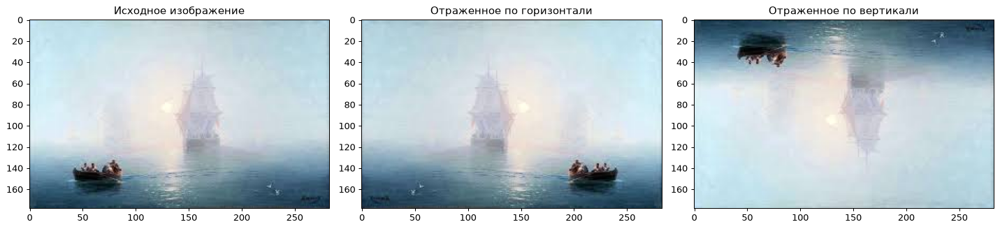

In [180]:
flip(aivazovsky)

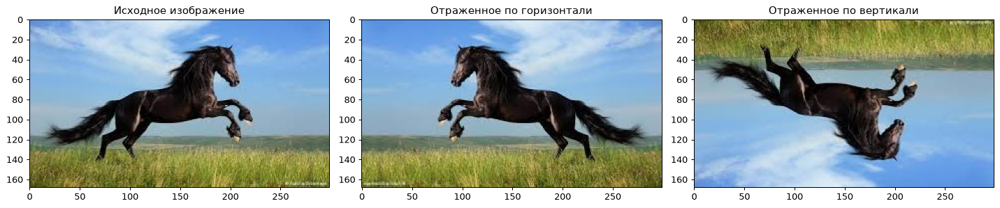

In [181]:
flip(horse)

## Поиск объекта на изображении

In [182]:
# переводим в HSV для удобства
bus_hsv = cv2.cvtColor(bus, cv2.COLOR_RGB2HSV)
car_hsv = cv2.cvtColor(car, cv2.COLOR_RGB2HSV)
fox_hsv = cv2.cvtColor(fox, cv2.COLOR_RGB2HSV)
tennis_ball_hsv = cv2.cvtColor(tennis_ball, cv2.COLOR_RGB2HSV)
aivazovsky_hsv = cv2.cvtColor(aivazovsky, cv2.COLOR_RGB2HSV)
horse_hsv = cv2.cvtColor(horse, cv2.COLOR_RGB2HSV)

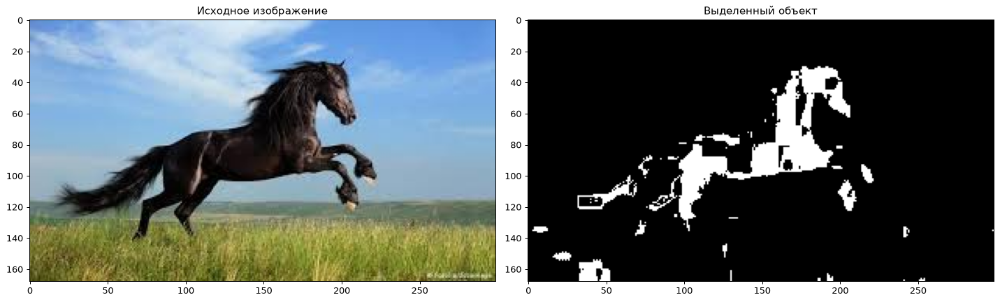

In [183]:
# подбираем цвета для выделения лошади
color_low = np.array([0, 0, 0])
color_high = np.array([25, 255, 255])
object = cv2.inRange(horse_hsv, color_low, color_high)
plt.figure(figsize=(16,13), dpi=90)
plt.subplot(1,2,1); plt.imshow(horse); plt.title('Исходное изображение')
plt.subplot(1,2,2); plt.imshow(object, cmap='gray'); plt.title('Выделенный объект')
plt.tight_layout()
plt.show()

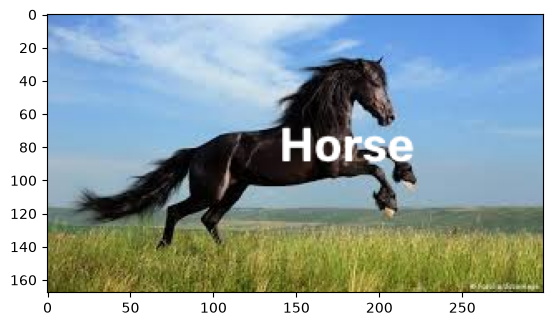

In [184]:
moments = cv2.moments(object, 1) # получаем моменты
x_moment = moments['m10']
y_moment = moments['m01']
area = moments['m00']
x = int(x_moment / area) # получаем координаты x, y для объекта
y = int(y_moment / area) # и вывводим текст на изображение
cv2.putText(horse, "Horse", (x,y), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)

plt.imshow(horse)

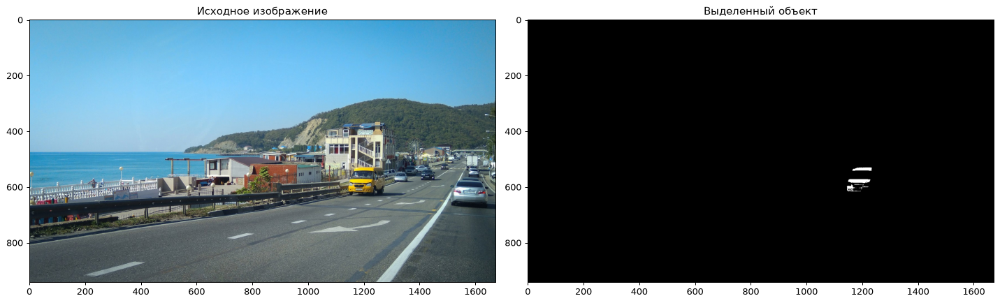

In [185]:
# подбираем цвета для выделения автобуса
color_low = np.array([9, 144, 210])
color_high = np.array([31, 255, 255])
object = cv2.inRange(bus_hsv, color_low, color_high)
plt.figure(figsize=(16,13), dpi=90)
plt.subplot(1,2,1); plt.imshow(bus); plt.title('Исходное изображение')
plt.subplot(1,2,2); plt.imshow(object, cmap='gray'); plt.title('Выделенный объект')
plt.tight_layout()
plt.show()

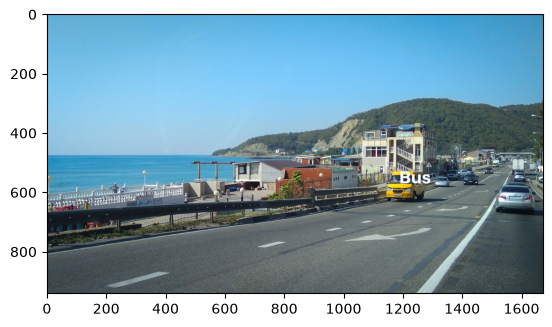

In [186]:
moments = cv2.moments(object, 1) # получаем моменты
x_moment = moments['m10']
y_moment = moments['m01']
area = moments['m00']
x = int(x_moment / area) # получаем координаты x, y для объекта
y = int(y_moment / area) # и вывводим текст на изображение
cv2.putText(bus, "Bus", (x,y), cv2.FONT_HERSHEY_SIMPLEX, 2, (255,255,255), 2)

plt.imshow(bus)

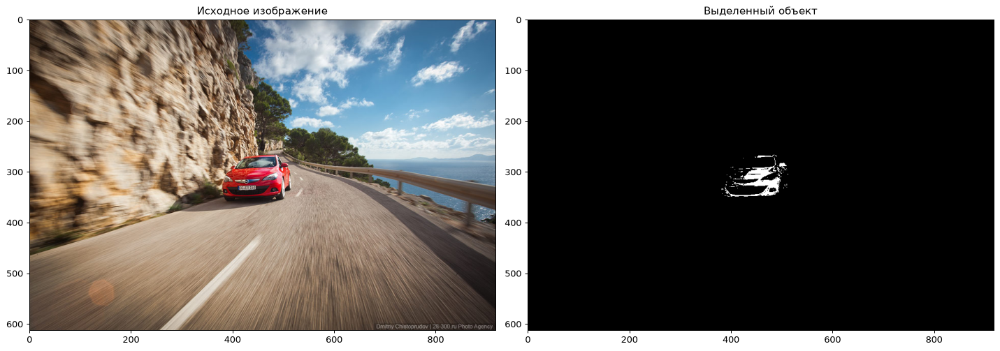

In [187]:
# подбираем цвета для выделения автомобиля
color_low = np.array([118, 87, 65])
color_high = np.array([179, 255, 255])
object = cv2.inRange(car_hsv, color_low, color_high)
plt.figure(figsize=(16,13), dpi=90)
plt.subplot(1,2,1); plt.imshow(car); plt.title('Исходное изображение')
plt.subplot(1,2,2); plt.imshow(object, cmap='gray'); plt.title('Выделенный объект')
plt.tight_layout()
plt.show()

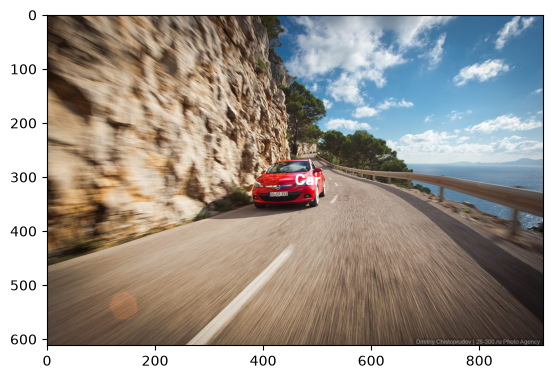

In [188]:
moments = cv2.moments(object, 1) # получаем моменты
x_moment = moments['m10']
y_moment = moments['m01']
area = moments['m00']
x = int(x_moment / area) # получаем координаты x, y для объекта
y = int(y_moment / area) # и вывводим текст на изображение
cv2.putText(car, "Car", (x,y), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)

plt.imshow(car)

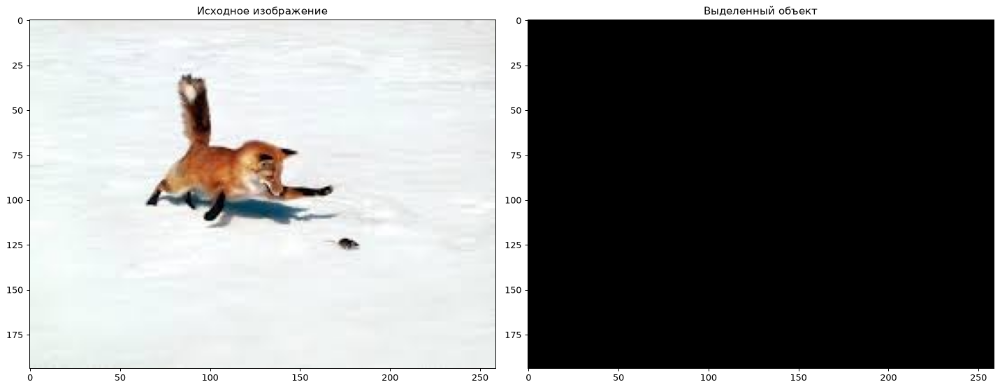

In [189]:
# подбираем цвета для выделения лисы
color_low = np.array([118, 87, 65])
color_high = np.array([179, 255, 255])
object = cv2.inRange(fox_hsv, color_low, color_high)
plt.figure(figsize=(16,13), dpi=90)
plt.subplot(1,2,1); plt.imshow(fox); plt.title('Исходное изображение')
plt.subplot(1,2,2); plt.imshow(object, cmap='gray'); plt.title('Выделенный объект')
plt.tight_layout()
plt.show()